In [1]:
from src.OLS import OLS
from src.stat_tests import RESET, VIF, AR1, COOKS_D, CHOW, WALD

import pandas as pd
import numpy as np
np.set_printoptions(suppress=True, precision=6)

from scipy.stats import norm, t as t_dist
from statsmodels.graphics.tsaplots import plot_ccf

import matplotlib.pyplot as plt
import matplotlib as mpl

# mpl.rcParams['figure.dpi'] = 300 # uncomment when outputting figures for the paper
A4P = (8.27, 11.69)
A4L = (11.69, 8.27)

In [2]:
data_kw = {'encoding': 'utf-8', 'low_memory': False}

rgdp = pd.read_csv('data/fred/GDPC1.csv', **data_kw)
rgdp = rgdp.set_index('observation_date').rename(columns={'GDPC1': 'Y'})
rgdp.index = pd.to_datetime(rgdp.index)

pce = pd.read_csv('data/fred/PCECC96.csv', **data_kw)
pce = pce.set_index('observation_date').rename(columns={'PCECC96': 'pce'})
pce.index = pd.to_datetime(pce.index)
pce = pce.loc[rgdp.index]

pdi = pd.read_csv('data/fred/GPDIC1.csv', **data_kw)
pdi = pdi.set_index('observation_date').rename(columns={'GPDIC1': 'pdi'})
pdi.index = pd.to_datetime(pdi.index)
pdi = pdi.loc[rgdp.index]

govexp = pd.read_csv('data/fred/GCEC1.csv', **data_kw)
govexp = govexp.set_index('observation_date').rename(columns={'GCEC1': 'govexp'})
govexp.index = pd.to_datetime(govexp.index)
govexp = govexp.loc[rgdp.index]

odef = pd.read_csv('data/fred/GDPDEF.csv', **data_kw)
odef = odef.set_index('observation_date').rename(columns={'GDPDEF': 'odef'})
odef.index = pd.to_datetime(odef.index)
odef = odef.loc[rgdp.index]

unat = pd.read_csv('data/fred/NROU.csv', **data_kw)
unat = unat.set_index('observation_date').rename(columns={'NROU': 'u^*'})
unat.index = pd.to_datetime(unat.index)
unat = unat.loc[rgdp.index]

unrate = pd.read_csv('data/fred/LRUN64TTUSQ156S.csv', **data_kw)
unrate = unrate.set_index('observation_date').rename(columns={'LRUN64TTUSQ156S': 'u'})
unrate.index = pd.to_datetime(unrate.index)
unrate = unrate.loc[rgdp.index]

ugap = pd.DataFrame(
    {
    "ugap": unrate['u'] - unat['u^*']
    })
# ugap = ugap - ugap.mean()

gdp_pot = pd.read_csv('data/fred/GDPPOT.csv', **data_kw)
gdp_pot = gdp_pot.set_index('observation_date').rename(columns={'GDPPOT': 'Y^*'})
gdp_pot.index = pd.to_datetime(gdp_pot.index)
gdp_pot = gdp_pot.loc[rgdp.index]

ogap = pd.DataFrame({
    "ogap": np.log(rgdp['Y']) - np.log(gdp_pot['Y^*']),
})
# ogap = ogap - ogap.mean()

netexp = pd.read_csv('data/fred/NETEXP.csv', **data_kw)
netexp = netexp.set_index('observation_date').rename(columns={'NETEXP': 'NETEXP'})
netexp.index = pd.to_datetime(netexp.index)
netexp = netexp.loc[rgdp.index]
netexp['NETEXP'] = netexp['NETEXP'] / rgdp['Y']
# Interactions
okun = pd.DataFrame({
    "okun": ugap['ugap'] * ogap['ogap'],
})

phillips = pd.DataFrame({
    "phillips": ugap['ugap'] * np.log(odef['odef']).diff(),
})

shock_dates = (
    # pd.Timestamp("2020-07-01"),
    # pd.Timestamp("2020-04-01"),
    pd.Timestamp("2008-10-01"),
)

In [3]:
target = np.log(rgdp).diff().dropna() * 100
fmt_regressors = [
    np.log(pce).diff().loc[target.index],
    np.log(pdi).diff().loc[target.index],
    np.log(govexp).diff().loc[target.index],
    # np.log(odef).diff().loc[target.index],
    ugap.loc[target.index].diff(),
    ogap.loc[target.index],

    okun.loc[target.index],    
    phillips.loc[target.index],
]
X = pd.concat(fmt_regressors, axis=1).shift(1).dropna()
t_idx = X.index
# shock_idx = [t_idx.get_loc(date) for date in shock_dates if date in t_idx]

dummies = []
for i, date in enumerate(shock_dates):
    dummy = pd.Series(0, index=t_idx)
    dummy.loc[date] = 1
    dummy.name = f"dummy_{i+1}"
    dummies.append(dummy)
X = pd.concat([X] + dummies, axis=1)
t_idx = t_idx[:-21]\
    # .where(~t_idx[:-21].isin(shock_dates)).dropna()

X = X.loc[t_idx]
y = target.loc[t_idx]

In [4]:
fit = OLS(
    X=X.values,
    y=y.values.flatten(),
).fit(diagnosis_alpha=0.05, diagnosis_trend='n')
fit.error

R2: 0.4577
R2_ADJ: 0.4121
RMSE: 0.4286
MAPE: 0.8049

In [5]:
VIF(X)

array([1.568206, 1.754109, 1.572345, 2.33943 , 3.889918, 2.548624,
       3.023513, 1.215479])

In [6]:
RESET(
    X=X,
    y=y.values.flatten(),
    q=2
)

reject: False
pval: 0.3837015070968538
test_stat: 0.9665989083812704
stat_name: RESET Test (F-Statistic)

In [7]:
t = {'_const': fit.T_tests[0]}
for i, var in enumerate(X.columns):
    t[var] = fit.T_tests[i+1]
{k: round(v.pval, 4) for k, v in t.items()}

{'_const': 0.0059,
 'pce': 0.0,
 'pdi': 0.0088,
 'govexp': 0.1942,
 'ugap': 0.9135,
 'ogap': 0.0234,
 'okun': 0.8179,
 'phillips': 0.0157,
 'dummy_1': 0.0006}

In [27]:
fit.intercept.round(4), fit.coefs.round(4).astype(float)

(np.float64(0.2714),
 array([ 54.3276,   4.8823,  -9.5442,   0.0241, -10.5652,   0.2778,
        -24.2331,  -1.7381]))

In [9]:
fit.F_test

reject: True
pval: 4.7240211742405336e-11
test_stat: 10.033238202796976
stat_name: F Test (F-Statistic)

In [10]:
fit.XT_e

np.float64(2.0028087261564353e-14)

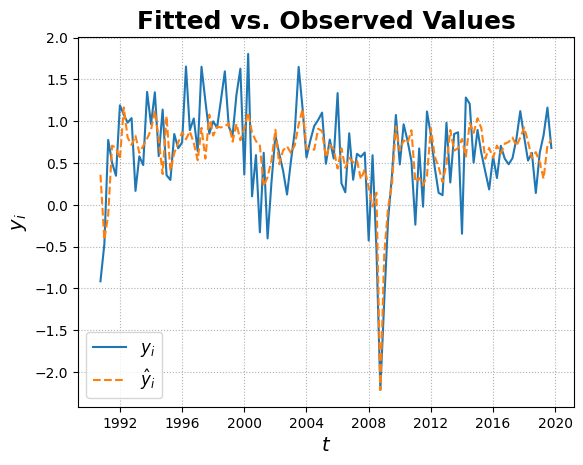

In [11]:
plt.plot(t_idx, y, label=r"$y_i$")
plt.plot(t_idx, fit.fitted_values, label=r"$\hat{y}_i$", linestyle='--')


plt.title(r"Fitted vs. Observed Values", fontsize=18, weight='bold')
plt.grid(alpha=1, linestyle=":")
plt.tick_params(axis="x", rotation=0, labelsize=10)
plt.tick_params(axis="y", rotation=0, labelsize=10)

plt.ylabel(r"$y_i$", fontsize=14)
plt.xlabel(r"$t$", fontsize=14)

plt.legend(fontsize=12)
# plt.savefig('paper2/fig/fit_v_obs.png', dpi=300)
plt.show()

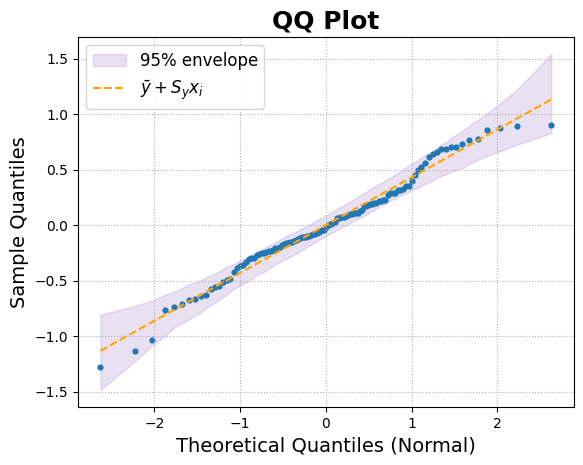

reject: False
pval: 0.13206617199056592
test_stat: 0.9825118309091888
stat_name: Shapiro-Wilk Test (Approximated Z-Statistic)

In [12]:
fit.qq(line='45')
fit.resid_normality

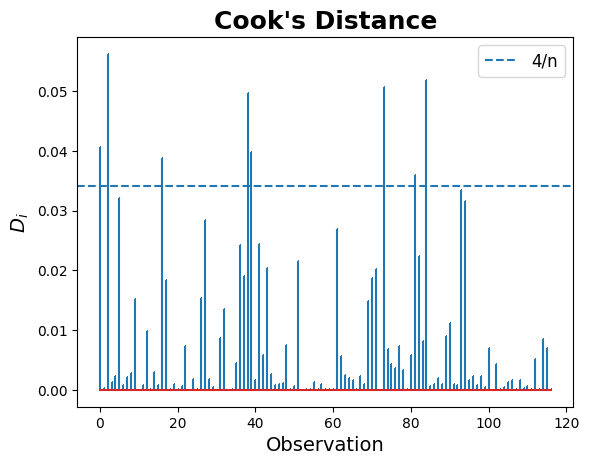

DatetimeIndex(['1990-10-01', '1991-04-01', '1994-10-01', '2000-04-01',
               '2000-07-01', '2009-01-01', '2011-01-01', '2011-10-01'],
              dtype='datetime64[ns]', name='observation_date', freq=None)

In [15]:
D, *_ = COOKS_D(
    X=X,
    y=y.values.flatten(),
    intercept=True,
    plot=True
)

obs = np.where(D > 4/len(t_idx))
t_idx[obs]

In [16]:
fit.resid_normality

reject: False
pval: 0.13206617199056592
test_stat: 0.9825118309091888
stat_name: Shapiro-Wilk Test (Approximated Z-Statistic)

In [17]:
fit.resid_heteroske

reject: False
pval: 0.4853610065052563
test_stat: 7.205433706426881
stat_name: Breusch-Pagan Test (Chi^2 Statistic)

In [18]:
fit.resid_autocorr[-2:]

[reject: False
 pval: 0.821978913296438
 test_stat: 10.190713109748447
 stat_name: BG(7) Test (Chi^2 Statistic),
 reject: False
 pval: 0.785060147766391
 test_stat: 10.7722649186305
 stat_name: BG(8) Test (Chi^2 Statistic)]

In [19]:
fit.resid_stationarity

reject: True
pval: 0.0035948782695114367
test_stat: -2.9057154161858074
stat_name: ADF Test (T-Statistic)

In [20]:
np.linalg.cond(X)

np.float64(75.63794968736033)

In [21]:
WALD(
    X=X.values,
    y=y.values.flatten(),
    joint_idx=[
        X.columns.get_loc('okun'),
        X.columns.get_loc('ugap'),
        X.columns.get_loc('ogap'),
    ]
)

reject: True
pval: 0.0022816129597084123
test_stat: 5.150450542582602
stat_name: Wald Test(F-Statistic)

In [22]:
np.corrcoef(X[['okun', 'phillips']], rowvar=False)

array([[ 1.      , -0.605466],
       [-0.605466,  1.      ]])

Text(-2.1133409999999997, 0.30000000000000177, '2008Q4')

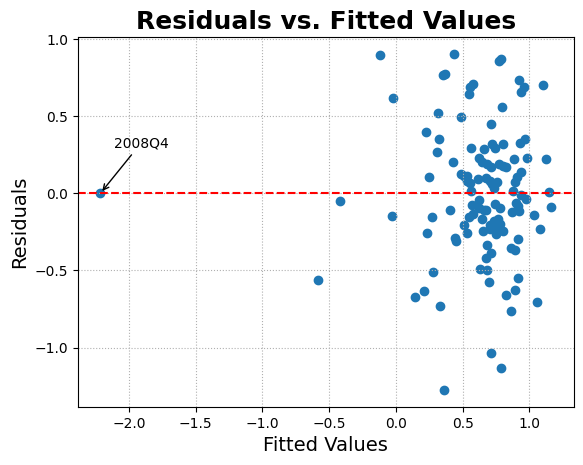

In [23]:
resid = fit.resid
fitted = fit.fitted_values

plt.scatter(fitted, resid)
plt.axhline(0, color='red', linestyle='--')
plt.title(r"Residuals vs. Fitted Values", fontsize=18, weight='bold')
plt.grid(alpha=1, linestyle=":")
plt.tick_params(axis="x", rotation=0, labelsize=10)
plt.tick_params(axis="y", rotation=0, labelsize=10)
plt.xlabel(r"Fitted Values", fontsize=14)
plt.ylabel(r"Residuals", fontsize=14)
plt.annotate(
    "2008Q4",
    xy=(
        -2.213341e+00,
        1.776357e-15,     
    ),
    xytext=(
        -2.213341e+00 + 0.1,
        1.776357e-15+0.3, 
    ),
    ha='left',
    arrowprops=dict(facecolor='black', arrowstyle='->')
)

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\s'
C:\Users\guney\AppData\Local\Temp\ipykernel_69752\2169099695.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, gaus_fit, label=f"Norm [$\mu={mu:,.1f}$, $\sigma={std:,.2f}$]")
C:\Users\guney\AppData\Local\Temp\ipykernel_69752\2169099695.py:7: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, gaus_fit, label=f"Norm [$\mu={mu:,.1f}$, $\sigma={std:,.2f}$]")


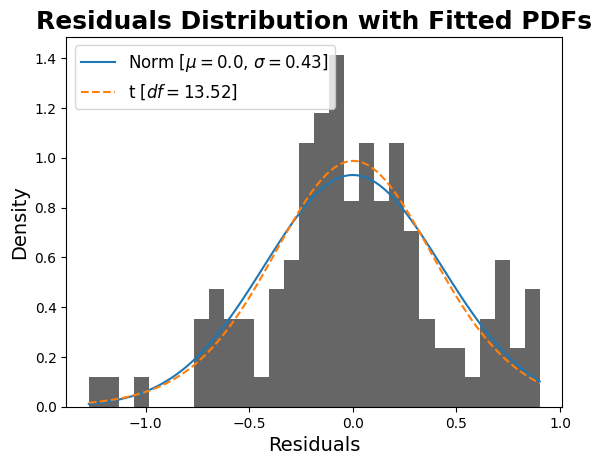

In [24]:
from scipy.stats import norm, t as t_dist
mu, std = norm.fit(resid)
ts = t_dist.fit(resid)
x = np.linspace(resid.min(), resid.max(), 100)
gaus_fit = norm.pdf(x, mu, std)
t_fit = t_dist.pdf(x, *ts)
plt.plot(x, gaus_fit, label=f"Norm [$\mu={mu:,.1f}$, $\sigma={std:,.2f}$]")
plt.plot(x, t_fit, label=f"t [$df={ts[0]:,.2f}$]", linestyle='--')
plt.hist(resid, bins=30, density=True, alpha=0.6, color='black')
plt.title(r"Residuals Distribution with Fitted PDFs", fontsize=18, weight='bold')
plt.tick_params(axis="x", rotation=0, labelsize=10)
plt.tick_params(axis="y", rotation=0, labelsize=10)
plt.xlabel(r"Residuals", fontsize=14)
plt.ylabel(r"Density", fontsize=14)
plt.legend(fontsize=12, loc='upper left')

In [25]:
df = pd.DataFrame(
    {
        'resid': resid,
        'fitted': fitted,
    }, index=t_idx
)
df.loc[df['resid'].abs().idxmin()]

resid     1.776357e-15
fitted   -2.213341e+00
Name: 2008-10-01 00:00:00, dtype: float64